In [41]:
import os
import pypsa
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import folium
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# ============================================================================
# PUBLISHABLE AESTHETICS SETUP
# ============================================================================
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.autolayout': True,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# ============================================================================
# CONFIGURATION 
# ============================================================================
RUN_NAME = "2020_baseline"
SIMPL    = ""
CLUSTERS = "10"
RDIR     = f"{RUN_NAME}/" if RUN_NAME else ""

# File Paths
BUSMAP_PATH  = f"../resources/{RDIR}bus_regions/busmap_elec_s{SIMPL}_{CLUSTERS}.csv"
PRE_NET      = f"../networks/{RDIR}elec_s{SIMPL}.nc"
SOLVED_NET   = f"../results/{RDIR}networks/elec_s_10_ec_lcopt_Co2L-3H.nc"
DEMAND_CSV   = f"../resources/{RDIR}demand_profiles.csv"
REGIONS_PATH = f"../resources/{RDIR}bus_regions/regions_onshore_elec_s{SIMPL}_{CLUSTERS}.geojson"
OUT_DIR      = "analysis/outputs/combined_analysis"

os.makedirs(OUT_DIR, exist_ok=True)

# Unified Color Palette
CARRIER_COLORS = {
    "solar": "#f9d71c", "onwind": "#235ebc", "offwind-ac": "#6895dd", "offwind-dc": "#74c6f2",
    "hydro": "#3dbfb0", "ror": "#298c81", "geothermal": "#ba2626", "biomass": "#8B4513",
    "CCGT": "#b35c00", "OCGT": "#e66c00", "coal": "#333333", "nuclear": "#E377C2",
    "oil": "#808080", "battery": "#9467BD", "load shedding": "#FF0000"
}

RENEWABLE_CARRIERS = ["solar", "onwind", "offwind-ac", "offwind-dc", "ror", "geothermal", "hydro", "biomass"]

print(f"Output directory ready: {OUT_DIR}/")

Output directory ready: analysis/outputs/combined_analysis/


In [42]:
print("=" * 80)
print("LOADING DATA & NETWORKS")
print("=" * 80)

# 1. Load Busmap
print(f"Loading busmap  : {BUSMAP_PATH}")
busmap = pd.read_csv(BUSMAP_PATH, index_col=0).squeeze("columns")
busmap.index = busmap.index.astype(str)
busmap.name = "cluster"

# 2. Load Geographic Regions
print(f"Loading regions : {REGIONS_PATH}")
try:
    regions_gdf = gpd.read_file(REGIONS_PATH)
    country_outline = regions_gdf.dissolve()
except Exception as e:
    print(f"⚠ WARNING: Could not load geographic regions ({e}). Maps will lack country borders.")
    regions_gdf = None
    country_outline = None

# 3. Load Pre-Clustering Network
print(f"Loading pre-net : {PRE_NET}")
n_pre = pypsa.Network(PRE_NET)

# 4. Load Solved Network
print(f"Loading solved  : {SOLVED_NET}")
n_solved = pypsa.Network(SOLVED_NET)

# Sanity Check for Solved Network
obj = getattr(n_solved, "objective", None)
if obj is None or (isinstance(obj, float) and np.isnan(obj)):
    print("\n⚠ WARNING: n_solved.objective is NaN — this may be the pre-solve network.")
else:
    print(f"  ✓ Network is solved. Objective value: {obj:,.0f}")

LOADING DATA & NETWORKS
Loading busmap  : ../resources/2020_baseline/bus_regions/busmap_elec_s_10.csv
Loading regions : ../resources/2020_baseline/bus_regions/regions_onshore_elec_s_10.geojson
Loading pre-net : ../networks/2020_baseline/elec_s.nc


INFO:pypsa.io:Imported network elec_s.nc has buses, carriers, generators, lines, links, loads, storage_units


Loading solved  : ../results/2020_baseline/networks/elec_s_10_ec_lcopt_Co2L-3H.nc


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


  ✓ Network is solved. Objective value: 4,092,641


1. BUSMAP OVERVIEW & PRE-CLUSTERING ANALYSIS
Original buses (pre-clustering): 59 | Resulting clusters: 10


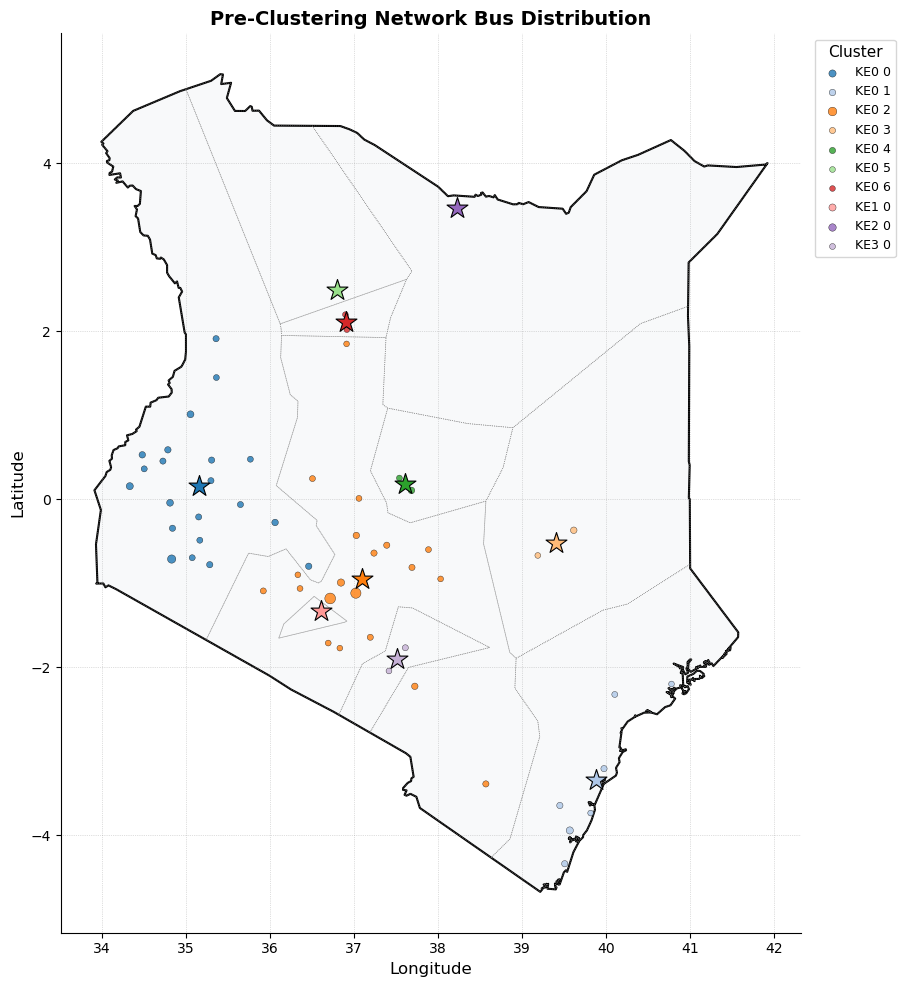

In [43]:
print("=" * 80)
print("1. BUSMAP OVERVIEW & PRE-CLUSTERING ANALYSIS")
print("=" * 80)

n_orig = len(busmap)
n_clusters = busmap.nunique()
print(f"Original buses (pre-clustering): {n_orig} | Resulting clusters: {n_clusters}")

buses_pre = n_pre.buses[["x", "y", "country", "carrier"]].copy()
buses_pre.index = buses_pre.index.astype(str)
buses_pre["cluster"] = busmap.reindex(buses_pre.index)

if not n_pre.loads_t.p_set.empty:
    avg_load = n_pre.loads_t.p_set.mean().rename_axis("load").to_frame("avg_load_MW")
    load_by_bus = n_pre.loads[["bus"]].join(avg_load).groupby("bus")["avg_load_MW"].sum()
else:
    load_by_bus = pd.Series(0.0, index=buses_pre.index)

buses_pre["avg_load_MW"] = load_by_bus.reindex(buses_pre.index, fill_value=0.0)

# ── Publishable Plot: Original Buses on Map ──
fig, ax = plt.subplots(figsize=(10, 10))

if country_outline is not None:
    country_outline.plot(ax=ax, facecolor='#f8f9fa', edgecolor='black', linewidth=1.5, zorder=1)
    regions_gdf.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=0.5, linestyle=':', zorder=2)

COLORS = plt.cm.tab20.colors
cluster_ids = sorted(busmap.unique())
color_map = {c: COLORS[i % len(COLORS)] for i, c in enumerate(cluster_ids)}

for cluster in cluster_ids:
    mask = buses_pre["cluster"] == cluster
    ax.scatter(buses_pre.loc[mask, "x"], buses_pre.loc[mask, "y"],
               s=buses_pre.loc[mask, "avg_load_MW"].clip(lower=5) * 0.4 + 15,
               color=color_map[cluster], alpha=0.8, edgecolor='black', linewidth=0.3, label=str(cluster), zorder=3)
    ax.scatter(buses_pre.loc[mask, "x"].mean(), buses_pre.loc[mask, "y"].mean(), 
               marker="*", s=250, color=color_map[cluster], edgecolors="black", linewidths=0.8, zorder=5)

ax.set_title("Pre-Clustering Network Bus Distribution", fontweight='bold')
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_aspect('equal')
ax.grid(color='grey', linestyle=':', linewidth=0.5, alpha=0.5)

fig.savefig(f"{OUT_DIR}/01_buses_by_cluster.png")
fig.savefig(f"{OUT_DIR}/01_buses_by_cluster.pdf")
plt.show()

In [44]:
print("=" * 80)
print("2. FINAL INSTALLED POWER MIX & STORAGE")
print("=" * 80)

gen = n_solved.generators.copy()
gen['Capacity_MW'] = gen['p_nom_opt']

tech_capacity = gen.groupby('carrier')['Capacity_MW'].sum().sort_values(ascending=False)
print("\nTotal Final Capacity by Technology (MW):")
print("-" * 50)
for tech, cap in tech_capacity.items():
    print(f"  {tech:.<40} {cap:>12.2f} MW")
print("-" * 50)
print(f"  {'TOTAL':.<40} {tech_capacity.sum():>12.2f} MW")

storage_units = n_solved.storage_units.copy()
storage_capacity = storage_units[storage_units['p_nom_opt'] > 0].copy()

print("\nInstalled Storage (Power & Energy):")
print("-" * 50)
if len(storage_capacity) > 0:
    for stype, pnom in storage_capacity.groupby('carrier')['p_nom_opt'].sum().items():
        print(f"  {stype:.<40} {pnom:>12.2f} MW")
    print("-" * 50)
    storage_capacity['energy_MWh'] = storage_capacity['p_nom_opt'] * storage_capacity['max_hours']
    for stype, en in storage_capacity.groupby('carrier')['energy_MWh'].sum().items():
        print(f"  {stype:.<40} {en:>12.2f} MWh")
else:
    print("  No active storage units found.")

2. FINAL INSTALLED POWER MIX & STORAGE

Total Final Capacity by Technology (MW):
--------------------------------------------------
  geothermal..............................      1100.50 MW
  oil.....................................       875.80 MW
  onwind..................................       435.50 MW
  solar...................................       256.50 MW
  ror.....................................       102.50 MW
  biomass.................................        13.40 MW
--------------------------------------------------
  TOTAL...................................      2784.20 MW

Installed Storage (Power & Energy):
--------------------------------------------------
  battery.................................         0.00 MW
  hydro...................................       725.00 MW
--------------------------------------------------
  battery.................................         0.00 MWh
  hydro...................................   1192706.10 MWh


3. EXISTING vs NEW CAPACITY COMPARISON

Carrier              Existing (MW)      New (MW)   Total (MW)    % New
---------------------------------------------------------------------------
  biomass *                   13.4           0.0         13.4     0.0%
  geothermal *              1100.5           0.0       1100.5     0.0%
  oil                        875.8           0.0        875.8     0.0%
  onwind *                   435.5           0.0        435.5     0.0%
  ror *                      102.5           0.0        102.5     0.0%
  solar *                    256.5           0.0        256.5     0.0%


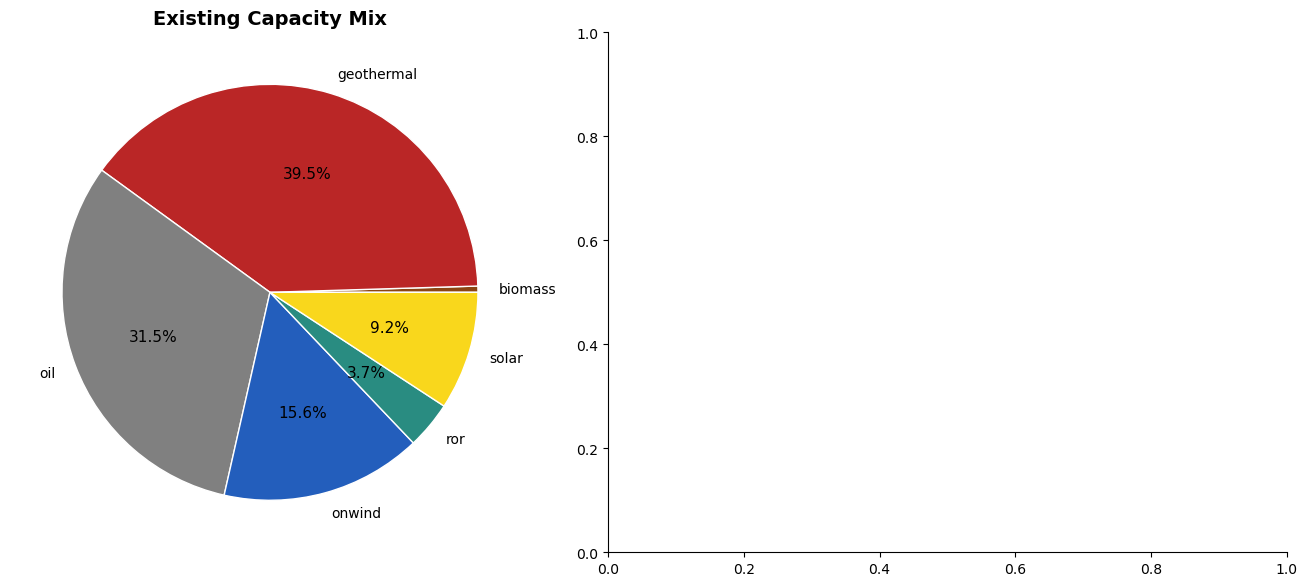

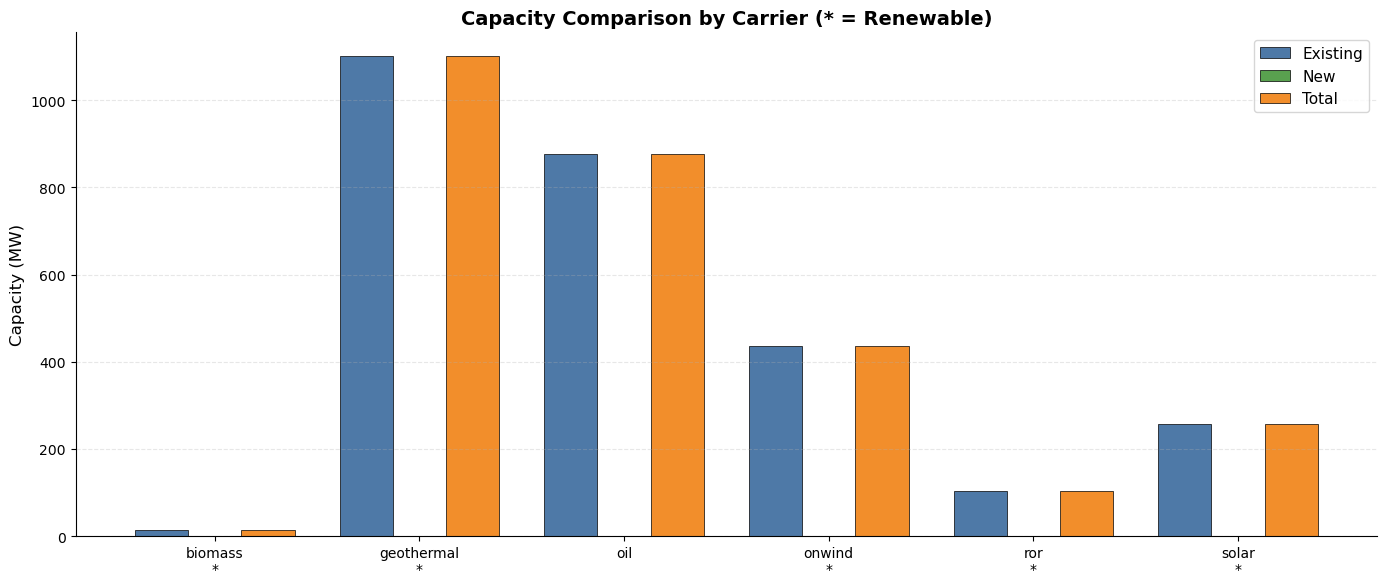

In [45]:
print("=" * 80)
print("3. EXISTING vs NEW CAPACITY COMPARISON")
print("=" * 80)

def classify(row):
    if not row["p_nom_extendable"]:
        return row["p_nom"], 0.0, row["p_nom"] 
    else:
        existing = row["p_nom_min"]            
        new = max(0.0, row["p_nom_opt"] - row["p_nom_min"])
        return existing, new, row["p_nom_opt"]

gen[["existing_MW", "new_MW", "total_MW"]] = gen.apply(classify, axis=1, result_type="expand")

summary_carriers = [c for c in gen["carrier"].unique() if gen.loc[gen["carrier"] == c, "total_MW"].sum() > 0]
print(f"\n{'Carrier':<18} {'Existing (MW)':>15} {'New (MW)':>13} {'Total (MW)':>12} {'% New':>8}")
print("-" * 75)
for c in sorted(summary_carriers):
    row = gen[gen["carrier"] == c]
    ex, nw, tot = row["existing_MW"].sum(), row["new_MW"].sum(), row["total_MW"].sum()
    pct = (nw / tot * 100) if tot > 0 else 0
    flag = " *" if c in RENEWABLE_CARRIERS else ""
    print(f"  {c+flag:<16} {ex:>15.1f} {nw:>13.1f} {tot:>12.1f} {pct:>7.1f}%")

# ── Publishable Pie Charts ──
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))

ex_by_carrier = {c: gen.loc[gen["carrier"] == c, "existing_MW"].sum() for c in summary_carriers}
ex_by_carrier = {k: v for k, v in ex_by_carrier.items() if v > 0}
axes1[0].pie(ex_by_carrier.values(), labels=ex_by_carrier.keys(), 
            colors=[CARRIER_COLORS.get(c, '#ccc') for c in ex_by_carrier], 
            autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
            wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes1[0].set_title("Existing Capacity Mix", fontweight='bold')

nw_by_carrier = {c: gen.loc[gen["carrier"] == c, "new_MW"].sum() for c in summary_carriers}
nw_by_carrier = {k: v for k, v in nw_by_carrier.items() if v > 0}
if nw_by_carrier:
    axes1[1].pie(nw_by_carrier.values(), labels=nw_by_carrier.keys(), 
                colors=[CARRIER_COLORS.get(c, '#ccc') for c in nw_by_carrier], 
                autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
                wedgeprops={'edgecolor': 'white', 'linewidth': 1})
    axes1[1].set_title("New Capacity Mix (Added by Optimiser)", fontweight='bold')

fig1.savefig(f"{OUT_DIR}/02_pie_existing_vs_new.png")
fig1.savefig(f"{OUT_DIR}/02_pie_existing_vs_new.pdf")
plt.show()

# ── Publishable Grouped Bar Chart ──
x = np.arange(len(summary_carriers))
w = 0.26
fig2, ax2 = plt.subplots(figsize=(14, 6))

ex_vals = [gen.loc[gen["carrier"] == c, "existing_MW"].sum() for c in summary_carriers]
nw_vals = [gen.loc[gen["carrier"] == c, "new_MW"].sum() for c in summary_carriers]
tot_vals = [gen.loc[gen["carrier"] == c, "total_MW"].sum() for c in summary_carriers]

ax2.bar(x - w, ex_vals, width=w, label="Existing", color="#4e79a7", edgecolor='black', linewidth=0.5)
ax2.bar(x, nw_vals, width=w, label="New", color="#59a14f", edgecolor='black', linewidth=0.5)
ax2.bar(x + w, tot_vals, width=w, label="Total", color="#f28e2b", edgecolor='black', linewidth=0.5)

ax2.set_xticks(x)
ax2.set_xticklabels([f"{c}\n*" if c in RENEWABLE_CARRIERS else c for c in summary_carriers], rotation=0)
ax2.set_ylabel("Capacity (MW)")
ax2.set_title("Capacity Comparison by Carrier (* = Renewable)", fontweight='bold')
ax2.legend()
ax2.grid(axis="y", alpha=0.3, linestyle='--')

fig2.savefig(f"{OUT_DIR}/03_bar_existing_vs_new.png")
fig2.savefig(f"{OUT_DIR}/03_bar_existing_vs_new.pdf")
plt.show()

4. SPATIAL DISTRIBUTION OF INSTALLED CAPACITY


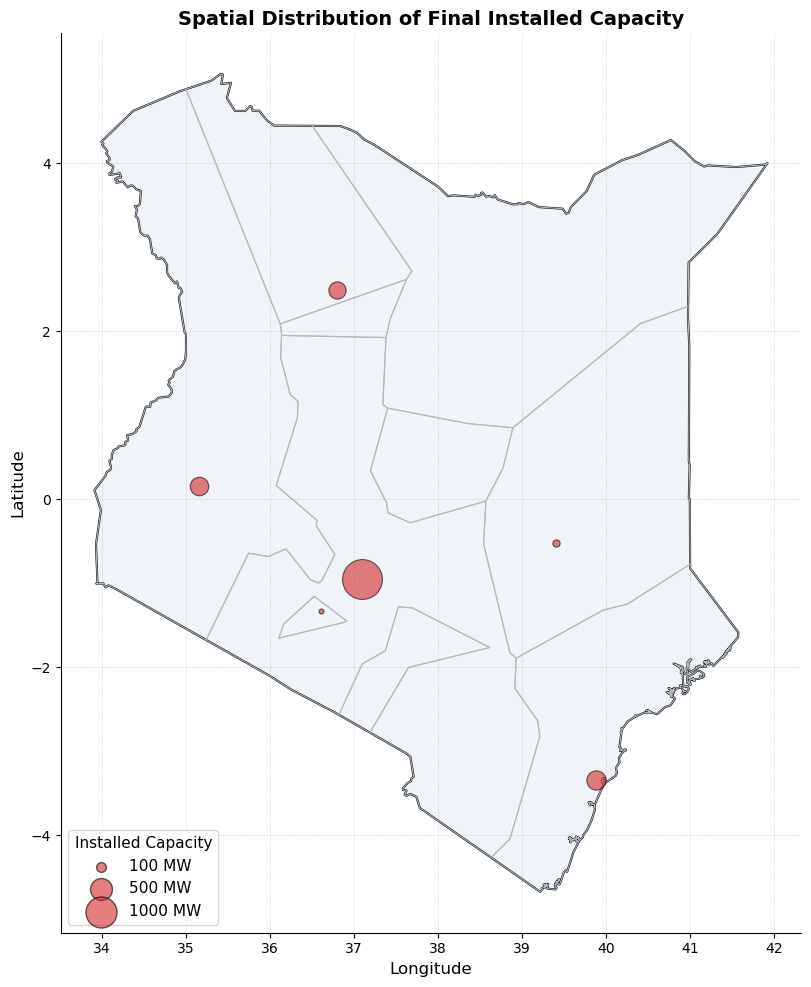


Interactive Map Preview:


In [46]:
print("=" * 80)
print("4. SPATIAL DISTRIBUTION OF INSTALLED CAPACITY")
print("=" * 80)

buses_in_kenya = n_solved.buses[n_solved.buses.index.str.contains('KE', case=False, na=False)].copy()
bus_capacities = gen.groupby('bus')['Capacity_MW'].sum()

# ── A. Publishable Static Capacity Map ──
fig, ax = plt.subplots(figsize=(10, 10))

if country_outline is not None:
    country_outline.plot(ax=ax, facecolor='#f0f4f8', edgecolor='black', linewidth=1.5, zorder=1)
    regions_gdf.plot(ax=ax, facecolor='none', edgecolor='#b0b8c4', linewidth=0.8, linestyle='-', zorder=2)

# Plot capacities as sized bubbles
for idx, row in buses_in_kenya.iterrows():
    if idx in bus_capacities and bus_capacities[idx] > 0:
        cap = bus_capacities[idx]
        ax.scatter(row['x'], row['y'], s=cap * 0.5, color='#d62728', alpha=0.6, 
                   edgecolor='black', linewidth=0.8, zorder=4)

# Create a custom size legend for the bubbles
legend_sizes = [100, 500, 1000]
legend_handles = [plt.scatter([], [], s=size * 0.5, color='#d62728', alpha=0.6, edgecolor='black') for size in legend_sizes]
ax.legend(legend_handles, [f"{size} MW" for size in legend_sizes], 
          title="Installed Capacity", loc='lower left', frameon=True)

ax.set_title("Spatial Distribution of Final Installed Capacity", fontweight='bold')
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_aspect('equal')
ax.grid(color='grey', linestyle=':', linewidth=0.5, alpha=0.5)

fig.savefig(f"{OUT_DIR}/04_static_capacity_map.png")
fig.savefig(f"{OUT_DIR}/04_static_capacity_map.pdf")
plt.show()

# ── B. Interactive Folium Map (For Browser Exploration) ──
if len(buses_in_kenya) > 0:
    m = folium.Map(location=[buses_in_kenya['y'].mean(), buses_in_kenya['x'].mean()], zoom_start=6, tiles='CartoDB positron')
    max_capacity = bus_capacities.max()
    
    for idx, row in buses_in_kenya.iterrows():
        bus_gens = gen[gen['bus'] == idx]
        bus_cap = bus_gens['Capacity_MW'].sum()
        
        if bus_cap > 0:
            norm_cap = bus_cap / max_capacity
            color = '#800026' if norm_cap > 0.75 else '#bd0026' if norm_cap > 0.5 else '#fd8d3c' if norm_cap > 0.25 else '#fed976'
            
            mix = bus_gens.groupby('carrier')['Capacity_MW'].sum().sort_values(ascending=False)
            html = f"<div style='font-family: Arial;'><h4>{idx}</h4><b>Total: {bus_cap:.1f} MW</b><hr><table style='width: 100%;'>"
            for c, cp in mix.items():
                html += f"<tr><td>{c}</td><td style='text-align: right;'><b>{cp:.1f} MW</b></td></tr>"
            html += "</table></div>"
            
            folium.CircleMarker(
                location=[row['y'], row['x']], radius=np.sqrt(bus_cap/15), color=color,
                fill=True, fillOpacity=0.7, weight=1
            ).add_to(m)
            
            folium.Marker(
                location=[row['y'], row['x']],
                icon=folium.DivIcon(html=f"<div style='font-size:10px; font-weight:bold; color:black; width:60px; margin-left:-30px;'>{idx}</div>"),
                popup=folium.Popup(html, max_width=250)
            ).add_to(m)

    m.save(f'{OUT_DIR}/05_interactive_cluster_map.html')
    print("\nInteractive Map Preview:")
    display(m)

In [47]:
print("=" * 80)
print("5. TRANSMISSION & POWER FLOW UTILIZATION")
print("=" * 80)

lines = n_solved.lines.copy()
if hasattr(n_solved.lines_t, 'p0') and len(n_solved.lines_t.p0) > 0:
    avg_flows = n_solved.lines_t.p0.mean()
    sorted_flows = avg_flows.abs().sort_values(ascending=False)
    
    print(f"{'From':<10} {'To':<10} {'Avg Flow (MW)':>15} {'Capacity (MW)':>15} {'Util. %':>10}")
    print("-" * 65)
    
    total_avg = total_cap = 0
    for l_idx in sorted_flows.index:
        af = abs(avg_flows[l_idx])
        cap = lines.loc[l_idx, 's_nom_opt']
        util = (af / cap * 100) if cap > 0 else 0
        
        if af > 0.01:
            print(f"{lines.loc[l_idx, 'bus0']:<10} {lines.loc[l_idx, 'bus1']:<10} {af:>15.2f} {cap:>15.2f} {util:>9.1f}%")
            total_avg += af
            total_cap += cap
            
    print("-" * 65)
    print(f"Network Utilization: {(total_avg / total_cap * 100) if total_cap > 0 else 0:.2f}%")
else:
    print("No time-series line flow data available.")

5. TRANSMISSION & POWER FLOW UTILIZATION
From       To           Avg Flow (MW)   Capacity (MW)    Util. %
-----------------------------------------------------------------
KE0 0      KE0 2               190.64         3869.89       4.9%
KE0 1      KE0 2                70.66         4213.98       1.7%
KE0 2      KE1 0                44.56           76.50      58.3%
KE0 2      KE3 0                43.62           74.80      58.3%
KE0 2      KE0 6                41.51         3574.95       1.2%
KE0 5      KE0 6                40.72         3574.95       1.1%
KE0 0      KE0 5                34.65           49.49      70.0%
KE0 3      KE3 0                19.26           33.20      58.0%
KE0 2      KE0 4                16.47          442.40       3.7%
KE1 0      KE3 0                16.35           28.00      58.4%
KE0 1      KE3 0                15.02           25.53      58.8%
KE0 4      KE3 0                 9.44           16.58      56.9%
KE0 2      KE0 3                 4.03          1

6. TIME-SERIES DISPATCH (MONTHLY & 14-DAY)


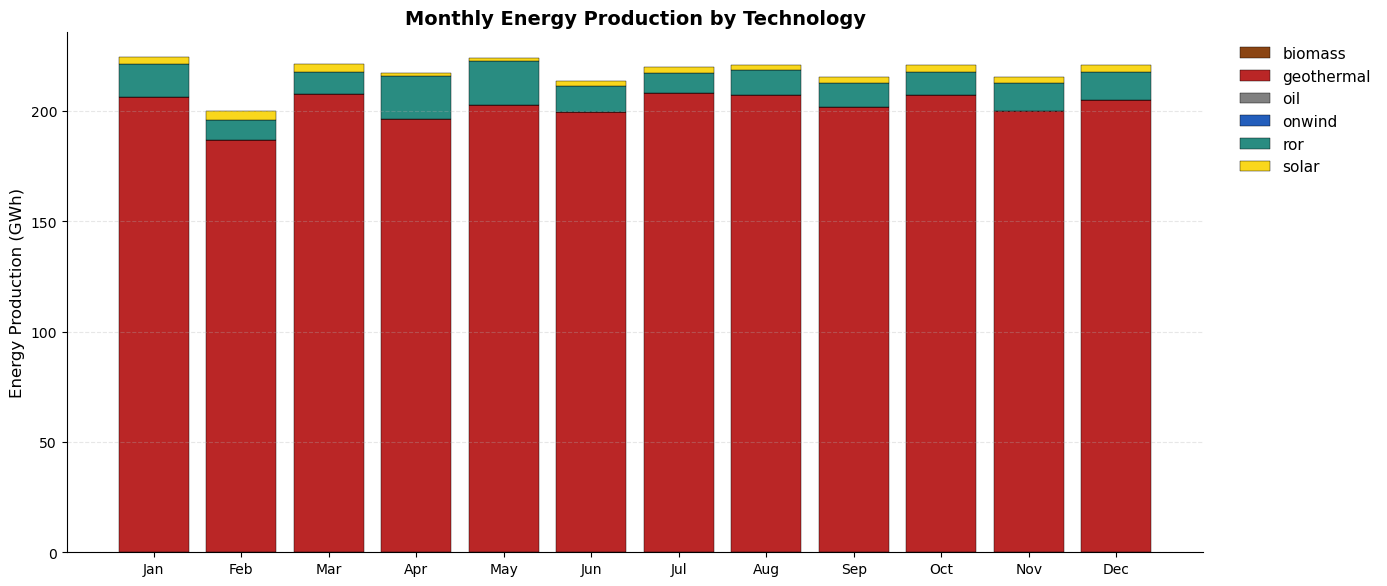

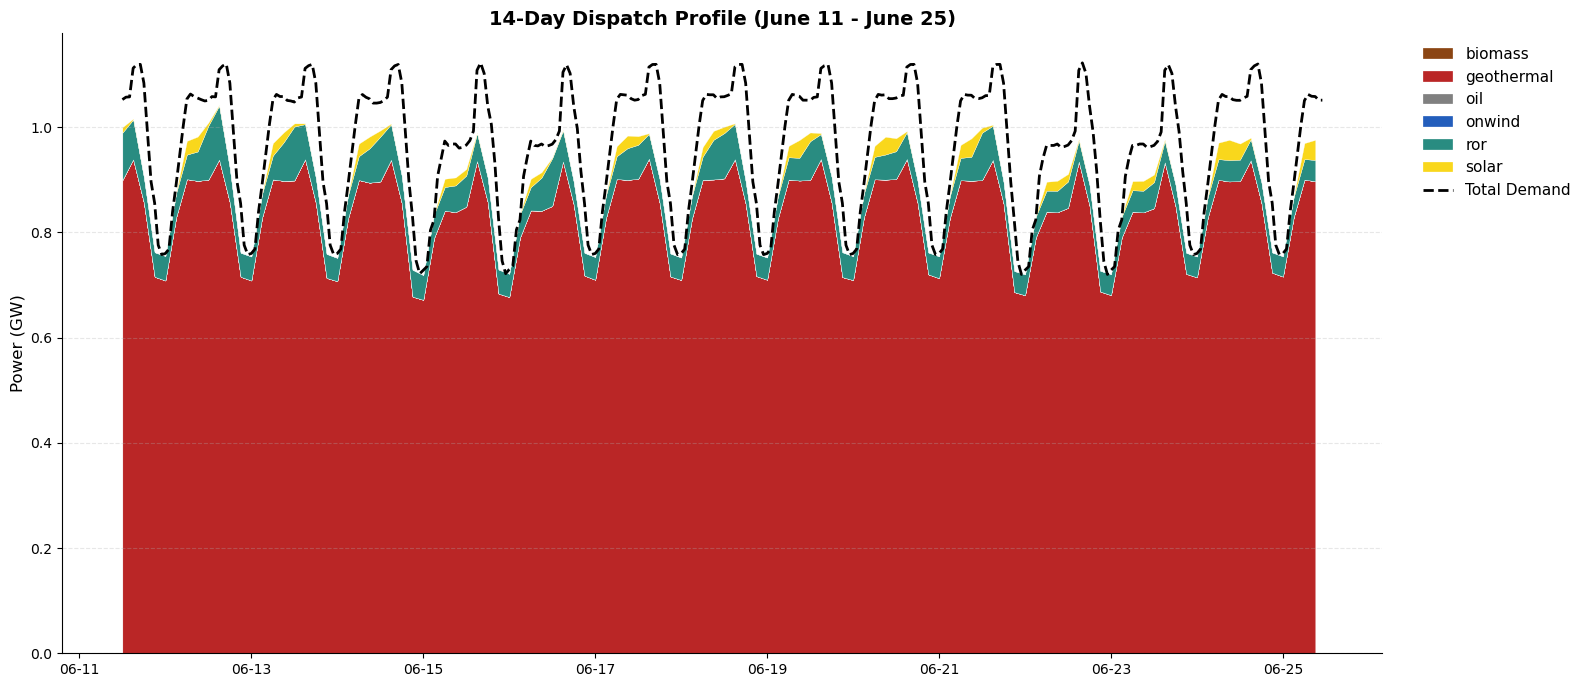

In [48]:
print("=" * 80)
print("6. TIME-SERIES DISPATCH (MONTHLY & 14-DAY)")
print("=" * 80)

if hasattr(n_solved.generators_t, 'p') and not n_solved.generators_t.p.empty:
    dispatch = n_solved.generators_t.p.copy()
    dispatch.index = pd.to_datetime(dispatch.index)
    
    # ── A. Publishable Monthly Stacked Bar ──
    monthly_by_carrier = pd.DataFrame()
    for carrier in gen['carrier'].unique():
        cols = gen[gen['carrier'] == carrier].index
        monthly_by_carrier[carrier] = dispatch[cols].sum(axis=1).resample('MS').sum() / 1e3 # GWh

    fig1, ax1 = plt.subplots(figsize=(14, 6))
    bottom = np.zeros(len(monthly_by_carrier))
    for carrier in sorted(monthly_by_carrier.columns):
        ax1.bar(range(len(monthly_by_carrier)), monthly_by_carrier[carrier], 
                bottom=bottom, label=carrier, color=CARRIER_COLORS.get(carrier, '#ccc'),
                edgecolor='black', linewidth=0.3)
        bottom += monthly_by_carrier[carrier].values
        
    ax1.set_xticks(range(len(monthly_by_carrier)))
    ax1.set_xticklabels([d.strftime('%b') for d in monthly_by_carrier.index])
    ax1.set_ylabel('Energy Production (GWh)')
    ax1.set_title('Monthly Energy Production by Technology', fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    
    fig1.savefig(f"{OUT_DIR}/06_monthly_dispatch.png")
    fig1.savefig(f"{OUT_DIR}/06_monthly_dispatch.pdf")
    plt.show()

    # ── B. Publishable 14-Day Dispatch Stacked Area ──
    start_date = dispatch.index[len(dispatch)//2 - 7*24] 
    end_date = start_date + pd.Timedelta(days=14)
    dispatch_14d = dispatch[(dispatch.index >= start_date) & (dispatch.index < end_date)]
    
    df_14d = pd.DataFrame()
    for carrier in gen['carrier'].unique():
        cols = gen[gen['carrier'] == carrier].index
        df_14d[carrier] = dispatch_14d[cols].sum(axis=1) / 1e3 # GW
        
    demand_14d = None
    try:
        dem = pd.read_csv(DEMAND_CSV, index_col=0)
        dem.index = pd.to_datetime(dem.index)
        demand_14d = dem.sum(axis=1).loc[start_date:end_date - pd.Timedelta(hours=1)] / 1e3
    except Exception as e:
        pass

    active_carriers = [c for c in sorted(df_14d.columns) if df_14d[c].sum() > 0]
    
    fig2, ax2 = plt.subplots(figsize=(16, 7))
    ax2.stackplot(df_14d.index, [df_14d[c] for c in active_carriers], 
                  labels=active_carriers, colors=[CARRIER_COLORS.get(c, '#ccc') for c in active_carriers],
                  edgecolor='white', linewidth=0.2)
    
    if demand_14d is not None:
        ax2.plot(demand_14d.index, demand_14d.values, color='black', ls='--', lw=2, label='Total Demand')
        
    ax2.set_ylabel('Power (GW)')
    ax2.set_title(f'14-Day Dispatch Profile ({start_date.strftime("%B %d")} - {end_date.strftime("%B %d")})', fontweight='bold')
    ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    plt.xticks(rotation=0)
    
    fig2.savefig(f"{OUT_DIR}/07_14_day_dispatch.png")
    fig2.savefig(f"{OUT_DIR}/07_14_day_dispatch.pdf")
    plt.show()
else:
    print("No time-series dispatch data available in the network.")